<a href="https://colab.research.google.com/github/santhosh1982/Youtube-Pytorch-Tutorial/blob/main/Diffusion_Image_Genration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Building a Diffusion Model for High-Resolution Image Generation with PyTorch

Diffusion models are a class of generative models that learn to reverse a gradual diffusion process, where noise is progressively added to data. By learning to denoise, they can generate high-quality, diverse samples from pure noise.

For high-resolution image generation, these models typically rely on a U-Net architecture to perform the denoising task. The process involves two main parts:

1.  **Forward Diffusion Process**: Gradually adding Gaussian noise to an image over several time steps.
2.  **Reverse Diffusion Process**: Learning to progressively remove noise from a noisy image (or pure noise) to reconstruct the original image.

In [1]:
# 1. Install necessary libraries (if not already installed)
# !pip install torch torchvision matplotlib numpy tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder # Or any other image dataset
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import math

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. U-Net Architecture

The U-Net is a convolutional neural network known for its U-shaped architecture, which allows it to capture context at different scales and precisely localize features. It consists of an encoder (downsampling path) that captures context, a bottleneck, and a decoder (upsampling path) that enables precise localization. Skip connections between the encoder and decoder are crucial for preserving fine-grained details.

For diffusion models, the U-Net predicts the noise that was added to an image at a specific timestep.

In [2]:
import math

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout_rate) # Add dropout
        )

    def forward(self, x):
        return self.block(x)

class UpConvBlock(nn.Module):
    def __init__(self, in_channels_from_down, skip_connection_channels, out_channels, dropout_rate=0.0):
        super().__init__()
        # Transposed convolution to upsample the input from the lower layer (x1)
        self.up = nn.ConvTranspose2d(in_channels_from_down, in_channels_from_down // 2, kernel_size=2, stride=2)
        # Conv block after concatenation. Input channels will be from upsampled x1 + skip x2
        self.conv = ConvBlock((in_channels_from_down // 2) + skip_connection_channels, out_channels, dropout_rate)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # Pad x1 if its spatial dimensions don't match x2 (due to ConvTranspose2d output size)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                    diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        if self.dim % 2 == 1:
            embeddings = nn.functional.pad(embeddings, (0, 1))
        return embeddings

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=[64, 128, 256, 512], dropout_rate=0.1):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down part of UNet
        current_in_channels = in_channels
        for feature in features:
            self.downs.append(ConvBlock(current_in_channels, feature, dropout_rate))
            current_in_channels = feature

        self.bottleneck = ConvBlock(features[-1], features[-1] * 2, dropout_rate)

        # Up part of UNet
        # First upsampling step: from bottleneck output to highest resolution skip connection
        # in_channels_from_down: channels from the bottleneck output (features[-1] * 2)
        # skip_connection_channels: channels from the last encoder block (features[-1])
        # out_channels: desired output channels for this block (features[-1])
        self.ups.append(UpConvBlock(features[-1] * 2, features[-1], features[-1], dropout_rate))

        # Remaining upsampling steps
        # Iterate from the second-to-last feature down to the first feature
        for i in range(len(features) - 2, -1, -1): # i will be 2, 1, 0 for features=[64, 128, 256, 512]
            in_from_down_channels = features[i+1] # Channels coming from the previous upsampled layer
            skip_connection_channels = features[i]  # Channels from the corresponding skip connection
            output_channels = features[i]           # Desired output channels for this block
            self.ups.append(UpConvBlock(in_from_down_channels, skip_connection_channels, output_channels, dropout_rate))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

        # Time embedding layer for diffusion models
        self.time_proj = SinusoidalPositionEmbeddings(features[0])
        self.time_mlp = nn.Sequential(
            nn.Linear(features[0], features[-1] * 2), # Output dimension to match bottleneck
            nn.ReLU(),
            nn.Linear(features[-1] * 2, features[-1] * 2) # Ensure final output matches bottleneck
        )

    def forward(self, x, t):
        skip_connections = []

        # Time embedding
        t_sin_embed = self.time_proj(t * TIMESTEPS) # Scale t back to original timestep range for embedding
        t_embed = self.time_mlp(t_sin_embed).unsqueeze(-1).unsqueeze(-1)

        # Downsampling path
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        # Add time embedding to bottleneck output
        x = x + t_embed # Simple addition, more complex integrations are common

        # Upsampling path
        skip_connections = skip_connections[::-1] # Reverse for upsampling
        for idx, up in enumerate(self.ups):
            x = up(x, skip_connections[idx])

        return self.final_conv(x)

## 3. Diffusion Process (Forward and Backward)

### Forward Diffusion (Adding Noise)

The forward process gradually adds Gaussian noise to an image over `T` timesteps. The amount of noise added at each step is controlled by a variance schedule (e.g., linear, cosine). We define `betas` (variance schedule) and `alphas` (1 - betas) to calculate `alpha_bars` (cumulative product of alphas), which helps in directly sampling a noisy image at any timestep `t`.

### Reverse Diffusion (Denoising/Sampling)

The reverse process is what the model learns. Starting from pure Gaussian noise, the model (U-Net) iteratively predicts the noise component added at each step `t`, or predicts the denoised image directly. By subtracting the predicted noise, the image is gradually denoise until a clean image is generated.

In [3]:
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start, end, timesteps)

def get_index_from_list(vals, t, x_shape):
    batch_size = t.shape[0]
    # Ensure 't' is on the same device as 'vals' before gathering
    out = vals.gather(-1, t.to(vals.device))
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

def forward_diffusion_sample(x0, t, timesteps, device):
    """
    Takes an image and a timestep as input and returns the noisy version of the image
    """
    betas = linear_beta_schedule(timesteps).to(device)
    alphas = 1. - betas
    alpha_bars = torch.cumprod(alphas, dim=0)

    sqrt_alpha_bar = get_index_from_list(torch.sqrt(alpha_bars), t, x0.shape)
    sqrt_one_minus_alpha_bar = get_index_from_list(torch.sqrt(1. - alpha_bars), t, x0.shape)

    # Generate random noise
    epsilon = torch.randn_like(x0)

    # Apply forward diffusion equation
    noisy_image = sqrt_alpha_bar * x0 + sqrt_one_minus_alpha_bar * epsilon
    return noisy_image, epsilon

# Parameters for diffusion process
TIMESTEPS = 1000 # Number of diffusion steps

## 4. Data Loading (Placeholder)

For high-resolution images, data loading can be critical. You would typically use `torchvision.datasets.ImageFolder` or a custom dataset class to load your images. Transformations are essential to resize, normalize, and potentially augment the data. Ensure that your images are of a consistent size (e.g., 256x256, 512x512, or higher) for high-resolution generation.

In [4]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder # Ensure ImageFolder is available
from torch.utils.data import DataLoader # Ensure DataLoader is available

# Define image size and batch size
IMAGE_SIZE = 64 # Example: start with a smaller size, scale up for high-res
BATCH_SIZE = 4

# Define transforms
image_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # Resize images
    transforms.ToTensor(), # Convert to tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalize to [-1, 1]
])

# Use ImageFolder for your custom dataset
# Replace 'path/to/your/high_res_image_folder' with '/content/vehicles_datasets'
dataset = ImageFolder(root='/content/vehicles_datasets', transform=image_transforms)

dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Number of batches: {len(dataloader)}")
print(f"Number of images: {len(dataset)}")

Number of batches: 575
Number of images: 2297


## 5. Training Loop

The training objective for a diffusion model is to learn to predict the noise that was added to an image. At each training step:

1.  A batch of original images (`x0`) is sampled.
2.  A random timestep `t` is sampled for each image in the batch.
3.  Noise (`epsilon`) is generated, and a noisy image (`xt`) is created using the forward diffusion process.
4.  The U-Net model predicts the noise (`pred_noise`) from the noisy image `xt` at timestep `t`.
5.  The loss (e.g., Mean Squared Error) is calculated between the predicted noise and the actual noise (`epsilon`).
6.  The model parameters are updated using an optimizer.

In [ ]:
# Initialize model, optimizer, and loss function
model = UNet(in_channels=3, out_channels=3, features=[64, 128, 256, 512], dropout_rate=0.1).to(device)

model.load_state_dict(torch.load('/content/drive/MyDrive/diffusion_model.pth'))

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

EPOCHS = 200 # Number of training epochs (increased for better quality)

# Training loop
print("Starting training...")
for epoch in range(EPOCHS):
    for batch_idx, (images, _) in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")):
        optimizer.zero_grad()
        images = images.to(device)

        # Sample a random timestep for each image in the batch
        t = torch.randint(0, TIMESTEPS, (images.shape[0],), device=device).long()

        # Apply forward diffusion to get noisy image and actual noise
        noisy_images, true_noise = forward_diffusion_sample(images, t, TIMESTEPS, device)
        # print(noisy_images[0].shape)
        # Predict noise using the U-Net model
        predicted_noise = model(noisy_images, t.float() / TIMESTEPS)

        # Calculate loss
        loss = criterion(predicted_noise, true_noise)

        # Backpropagate and update weights
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            tqdm.write(f"Epoch [{epoch+1}/{EPOCHS}], Batch [{batch_idx}/{len(dataloader)}], Loss: {loss.item():.4f}")

print("Training complete!")

torch.save(model.state_dict(), 'diffusion_model.pth')
print("Model saved!")

!cp /content/diffusion_model.pth /content/drive/MyDrive/diffusion_model.pth

Starting training...


Epoch 1/200:   1%|          | 3/575 [00:00<00:25, 22.24it/s]

Epoch [1/200], Batch [0/575], Loss: 0.0185


Epoch 1/200:  18%|█▊        | 105/575 [00:03<00:17, 27.21it/s]

Epoch [1/200], Batch [100/575], Loss: 0.0139


...

Epoch 10/200:  70%|███████   | 405/575 [00:15<00:06, 26.99it/s]

Epoch [10/200], Batch [400/575], Loss: 0.0194


Epoch 10/200:  88%|████████▊ | 505/575 [00:18<00:02, 27.01it/s]

Epoch [10/200], Batch [500/575], Loss: 0.0209


Epoch 10/200:  97%|█████████▋| 556/575 [00:20<00:00, 26.87it/s]

## 6. Sampling (Reverse Diffusion for Image Generation)

After training, the model can generate new images by reversing the diffusion process. Starting from pure noise, the model iteratively denoises the image until a clean sample is produced. This usually involves calculating the denoised image at each step using the predicted noise and then adding a small amount of noise again (stochastic sampling) or directly predicting the clean image (deterministic sampling).

Generating 4 sample images...


Sampling progress: 1000it [00:11, 87.57it/s]


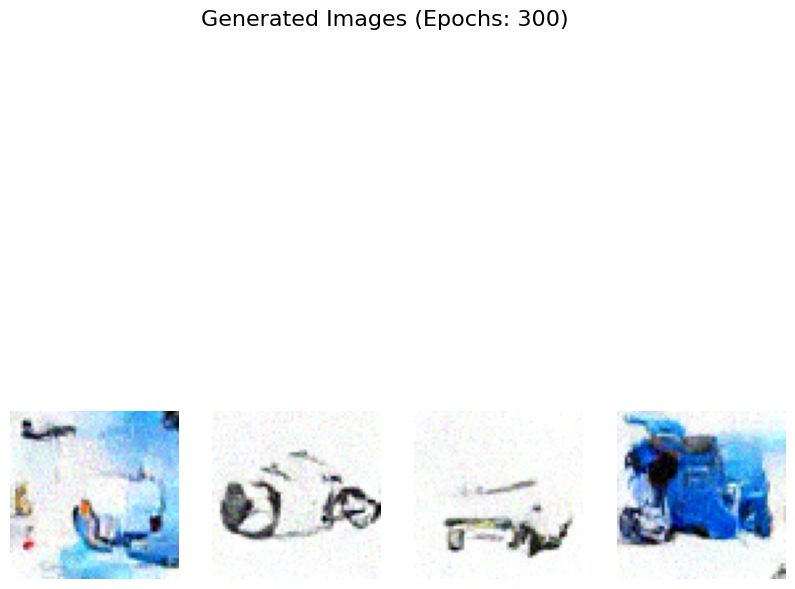

In [10]:
import torch # Added for robustness
import matplotlib.pyplot as plt # Added for robustness
from tqdm import tqdm # Added for robustness

@torch.no_grad()
def sample_diffusion_images(model, timesteps, img_size, num_images=4, channels=3, device='cpu'):
    # Model is in evaluation mode
    model.eval()

    # Start with pure noise
    x = torch.randn(num_images, channels, img_size, img_size, device=device)

    betas = linear_beta_schedule(timesteps).to(device)
    alphas = 1. - betas
    alpha_bars = torch.cumprod(alphas, dim=0)

    for i in tqdm(reversed(range(timesteps)), position=0, desc='Sampling progress'):
        t = torch.full((num_images,), i, device=device, dtype=torch.long)

        alpha = get_index_from_list(alphas, t, x.shape)
        alpha_bar = get_index_from_list(alpha_bars, t, x.shape)
        beta = get_index_from_list(betas, t, x.shape)

        # Predict noise (or directly denoise) using the trained model
        predicted_noise = model(x, t.float() / timesteps)

        # Calculate the denoised image using the formula from DDPMs
        # x_t-1 = 1/sqrt(alpha_t) * (x_t - beta_t/sqrt(1-alpha_bar_t) * epsilon_theta) + sigma_t * z

        # Coefficient for the mean
        mean_coeff = 1.0 / torch.sqrt(alpha)

        # Term for predicted noise
        predicted_noise_term = (beta / torch.sqrt(1.0 - alpha_bar)) * predicted_noise

        # Mean of the reverse process (x_{t-1})
        mean = mean_coeff * (x - predicted_noise_term)

        if i > 0: # Add noise for stochastic sampling
            # Variance of the reverse process
            variance = get_index_from_list(betas, t, x.shape)

            # Sample from a Gaussian distribution
            z = torch.randn_like(x)
            x = mean + torch.sqrt(variance) * z
        else: # For the last step, no noise is added
            x = mean

    # Normalize images back to [0, 1] for display
    x = (x.clamp(-1, 1) + 1) / 2
    x = x.cpu().permute(0, 2, 3, 1).numpy()
    return x

# --- Generate and display some sample images (after training) ---
# This will only work meaningfully after actual training.
# For this demonstration, the model is minimally trained with dummy data.

# Number of images to generate
NUM_SAMPLES = 4

!cp /content/drive/MyDrive/diffusion_model.pth /content/diffusion_model.pth
model = UNet(in_channels=3, out_channels=3, features=[64, 128, 256, 512], dropout_rate=0.1).to(device)
model.load_state_dict(torch.load('/content/diffusion_model.pth'))

print(f"Generating {NUM_SAMPLES} sample images...")
sampled_images = sample_diffusion_images(model, TIMESTEPS, IMAGE_SIZE, num_images=NUM_SAMPLES, device=device)

plt.figure(figsize=(10, 10))
for i in range(NUM_SAMPLES):
    plt.subplot(1, NUM_SAMPLES, i + 1)
    plt.imshow(sampled_images[i])
    plt.axis('off')
plt.suptitle(f"Generated Images (Epochs: {EPOCHS})", fontsize=16)
plt.show()

### Next Steps for High-Resolution Generation:

*   **Larger Model**: Increase `features` in `UNet` and potentially the depth (more down/up blocks).
*   **Higher Resolution Data**: Use actual high-resolution datasets and set `IMAGE_SIZE` accordingly.
*   **Longer Training**: Train for many more epochs on a GPU/TPU.
*   **Advanced Techniques**: Implement conditional generation (e.g., class-conditional), self-attention mechanisms in U-Net, improved noise schedules (cosine), or more sophisticated sampling techniques (DDIM).
*   **Classifier-Free Guidance**: For improved sample quality with conditional models.
*   **Memory Optimization**: For very high resolutions, techniques like gradient checkpointing or mixed-precision training might be necessary.